# 🐦 Bird Audio Classifier — Training Notebook

This notebook trains and evaluates **three models** for bird species classification from audio:
1. **Naive Baseline** — Majority class classifier
2. **Classical ML** — Random Forest on MFCC features
3. **Deep Learning** — CNN on Mel Spectrograms (EfficientNet-B0 fine-tuned)

**Dataset**: BirdCLEF 2023 scoped to North American species (top N by sample count)

**Experiment**: Training set size sensitivity — how does performance degrade with fewer samples per class?

## 0. Setup & Imports

In [1]:
# Install dependencies if needed
# !pip install librosa soundfile scikit-learn torch torchvision timm matplotlib seaborn tqdm kaggle

In [2]:
import os
import random
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from tqdm import tqdm
from collections import Counter

import librosa
import librosa.display
import soundfile as sf

from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, classification_report, confusion_matrix, f1_score
)
from sklearn.dummy import DummyClassifier

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as transforms
import timm

# Reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {DEVICE}')

Using device: cuda


## 1. Configuration

In [24]:
# from google.colab import drive
# drive.mount('/content/drive')

# ─── Paths ────────────────────────────────────────────────────────────────────
DATA_DIR      = Path('../data/raw')          # raw .ogg / .mp3 files from BirdCLEF
PROCESSED_DIR = Path('../data/processed')
MODELS_DIR    = Path('../models')
OUTPUTS_DIR   = Path('../data/outputs')

for d in [PROCESSED_DIR, MODELS_DIR, OUTPUTS_DIR]:
    d.mkdir(parents=True, exist_ok=True)

# ─── Scope ────────────────────────────────────────────────────────────────────
TOP_N_SPECIES   = 10       # keep top N species by sample count
MIN_SAMPLES     = 30       # drop species with fewer samples than this
AUDIO_DURATION  = 5        # seconds per clip
SAMPLE_RATE     = 22050

# ─── Mel Spectrogram ──────────────────────────────────────────────────────────
N_MELS   = 128
HOP_LEN  = 512
N_FFT    = 2048
IMG_SIZE = 224             # EfficientNet-B0 input size

# ─── Training ─────────────────────────────────────────────────────────────────
TEST_SIZE  = 0.2
VAL_SIZE   = 0.1
BATCH_SIZE = 32
EPOCHS     = 30
LR         = 1e-4

print('Config loaded.')
print(f'Scoping to top {TOP_N_SPECIES} North American species.')

Config loaded.
Scoping to top 10 North American species.


## 2. Data Loading & Scoping

**Dataset**: Download BirdCLEF 2023 from Kaggle:
```bash
kaggle competitions download -c birdclef-2023
unzip birdclef-2023.zip -d ../data/raw
```

Alternatively, use the `xeno-canto` API or eBird. The metadata CSV (`train_metadata.csv`) must be in `DATA_DIR`.

In [4]:
os.environ['KAGGLE_API_TOKEN'] = 'KGAT_144897c1d3d5c4c24e87e70242edc1ee'

In [5]:
!kaggle competitions list

ref                                                                              deadline             category         reward  teamCount  userHasEntered  
-------------------------------------------------------------------------------  -------------------  --------  -------------  ---------  --------------  
https://www.kaggle.com/competitions/passenger-screening-algorithm-challenge      2017-12-15 23:59:00  Featured  1,500,000 Usd        518           False  
https://www.kaggle.com/competitions/zillow-prize-1                               2018-01-10 15:59:00  Featured  1,200,000 Usd       3770           False  
https://www.kaggle.com/competitions/data-science-bowl-2017                       2017-04-12 23:59:00  Featured  1,000,000 Usd       1972           False  
https://www.kaggle.com/competitions/vesuvius-challenge-ink-detection             2023-06-14 23:59:00  Featured  1,000,000 Usd       1249           False  
https://www.kaggle.com/competitions/arc-prize-2026-arc-agi-3          

In [6]:
!kaggle competitions download -c birdclef-2023

100% 4.91G/4.91G [05:13<00:00, 16.8MB/s]



In [7]:
!unzip birdclef-2023.zip -d ../data/raw

Streaming output truncated to the last 5000 lines.
  inflating: ../data/raw/train_audio/rerswa1/XC330427.ogg  
  inflating: ../data/raw/train_audio/rerswa1/XC330925.ogg  
  inflating: ../data/raw/train_audio/rerswa1/XC331732.ogg  
  inflating: ../data/raw/train_audio/rerswa1/XC333007.ogg  
  inflating: ../data/raw/train_audio/rerswa1/XC333008.ogg  
  inflating: ../data/raw/train_audio/rerswa1/XC333855.ogg  
  inflating: ../data/raw/train_audio/rerswa1/XC334159.ogg  
  inflating: ../data/raw/train_audio/rerswa1/XC334160.ogg  
  inflating: ../data/raw/train_audio/rerswa1/XC334161.ogg  
  inflating: ../data/raw/train_audio/rerswa1/XC370598.ogg  
  inflating: ../data/raw/train_audio/rerswa1/XC371021.ogg  
  inflating: ../data/raw/train_audio/rerswa1/XC371367.ogg  
  inflating: ../data/raw/train_audio/rerswa1/XC376096.ogg  
  inflating: ../data/raw/train_audio/rerswa1/XC379520.ogg  
  inflating: ../data/raw/train_audio/rerswa1/XC381917.ogg  
  inflating: ../data/raw/train_audio/rerswa1/XC38

Loaded 234 samples across 4 species.


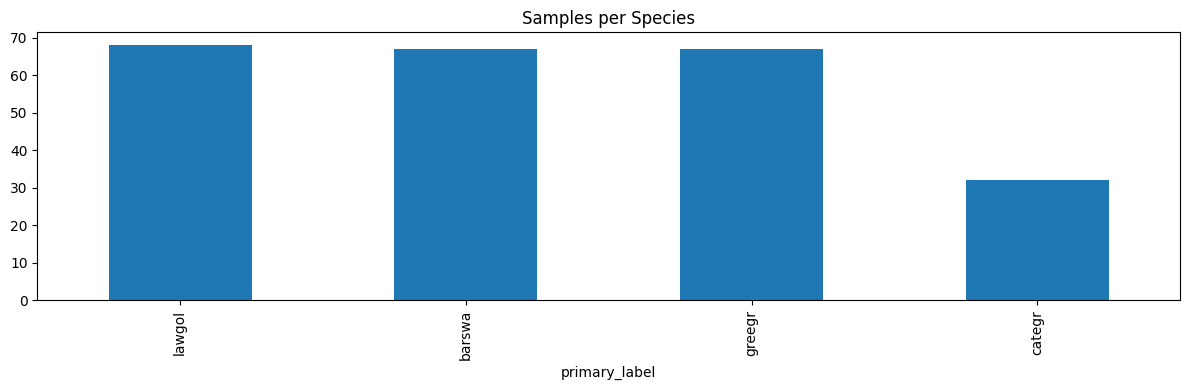

In [8]:
def load_metadata(data_dir: Path, top_n: int, min_samples: int) -> pd.DataFrame:
    """
    Load and filter BirdCLEF metadata to top N North American species.

    Args:
        data_dir:    Path to raw data directory containing train_metadata.csv
        top_n:       Number of top species (by sample count) to retain
        min_samples: Minimum samples per species required

    Returns:
        Filtered DataFrame with columns [filename, primary_label, ...]
    """
    meta_path = data_dir / 'train_metadata.csv'
    df = pd.read_csv(meta_path)

    # BirdCLEF has a 'country' or 'latitude' column — filter North America
    # Approximate bounding box: lat 15–72, lon -168 to -52
    if 'latitude' in df.columns and 'longitude' in df.columns:
        df = df[
            (df['latitude'].between(15, 72)) &
            (df['longitude'].between(-168, -52))
        ]

    # Count samples per species and keep top N with enough data
    counts = df['primary_label'].value_counts()
    valid_species = counts[counts >= min_samples].head(top_n).index.tolist()
    df = df[df['primary_label'].isin(valid_species)].reset_index(drop=True)

    print(f'Loaded {len(df)} samples across {df["primary_label"].nunique()} species.')
    return df


df_meta = load_metadata(DATA_DIR, TOP_N_SPECIES, MIN_SAMPLES)
df_meta['primary_label'].value_counts().plot(kind='bar', figsize=(12, 4), title='Samples per Species')
plt.tight_layout()
plt.savefig(OUTPUTS_DIR / 'species_distribution.png', dpi=150)
plt.show()

## 3. Feature Extraction

In [9]:
def load_audio(filepath: str, sr: int = SAMPLE_RATE, duration: int = AUDIO_DURATION) -> np.ndarray:
    """
    Load audio file, pad or trim to fixed duration.

    Args:
        filepath: Path to .ogg/.mp3 file
        sr:       Target sample rate
        duration: Desired clip length in seconds

    Returns:
        1D float32 numpy array of shape (sr * duration,)
    """
    target_len = sr * duration
    audio, _ = librosa.load(filepath, sr=sr, duration=duration, mono=True)

    # Pad if shorter than target
    if len(audio) < target_len:
        audio = np.pad(audio, (0, target_len - len(audio)), mode='constant')

    return audio[:target_len]


def extract_mfcc_features(audio: np.ndarray, sr: int = SAMPLE_RATE, n_mfcc: int = 40) -> np.ndarray:
    """
    Extract MFCC feature vector (mean + std over time) for classical ML.

    Args:
        audio:  1D audio signal
        sr:     Sample rate
        n_mfcc: Number of MFCC coefficients

    Returns:
        Feature vector of shape (n_mfcc * 2,)
    """
    mfcc = librosa.feature.mfcc(y=audio, sr=sr, n_mfcc=n_mfcc)
    return np.concatenate([mfcc.mean(axis=1), mfcc.std(axis=1)])


def compute_mel_spectrogram(audio: np.ndarray, sr: int = SAMPLE_RATE) -> np.ndarray:
    """
    Compute log-scaled mel spectrogram for CNN input.

    Args:
        audio: 1D audio signal
        sr:    Sample rate

    Returns:
        2D array of shape (N_MELS, time_frames) in dB scale
    """
    mel = librosa.feature.melspectrogram(
        y=audio, sr=sr, n_mels=N_MELS, n_fft=N_FFT, hop_length=HOP_LEN
    )
    return librosa.power_to_db(mel, ref=np.max)

In [10]:
def build_feature_arrays(
    df: pd.DataFrame,
    data_dir: Path,
    audio_subdir: str = 'train_audio'
) -> tuple:
    """
    Extract MFCC features and mel spectrograms for all samples.

    Args:
        df:           Filtered metadata DataFrame
        data_dir:     Root data directory
        audio_subdir: Subdirectory containing species folders of audio

    Returns:
        Tuple of (X_mfcc, X_mel, labels) as numpy arrays
    """
    X_mfcc, X_mel, labels = [], [], []
    failed = 0

    for _, row in tqdm(df.iterrows(), total=len(df), desc='Extracting features'):
        filepath = data_dir / audio_subdir / row['filename']
        try:
            audio = load_audio(str(filepath))
            X_mfcc.append(extract_mfcc_features(audio))
            X_mel.append(compute_mel_spectrogram(audio))
            labels.append(row['primary_label'])
        except Exception as e:
            failed += 1

    print(f'Done. Failed to load: {failed}/{len(df)} files.')
    return np.array(X_mfcc), np.array(X_mel), np.array(labels)


X_mfcc, X_mel, y_raw = build_feature_arrays(df_meta, DATA_DIR)

# Encode labels
le = LabelEncoder()
y = le.fit_transform(y_raw)
NUM_CLASSES = len(le.classes_)
print(f'Classes: {NUM_CLASSES} | MFCC shape: {X_mfcc.shape} | Mel shape: {X_mel.shape}')

# Save processed features
np.save(PROCESSED_DIR / 'X_mfcc.npy', X_mfcc)
np.save(PROCESSED_DIR / 'X_mel.npy', X_mel)
np.save(PROCESSED_DIR / 'y.npy', y)
np.save(PROCESSED_DIR / 'classes.npy', le.classes_)

Extracting features: 100%|██████████| 234/234 [00:22<00:00, 10.51it/s]

Done. Failed to load: 0/234 files.
Classes: 4 | MFCC shape: (234, 80) | Mel shape: (234, 128, 216)


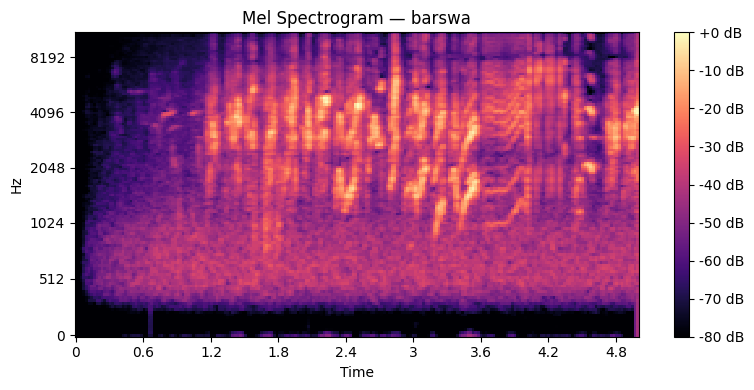

In [11]:
# ─── Quick sanity-check: plot a sample mel spectrogram ────────────────────────
fig, ax = plt.subplots(figsize=(8, 4))
img = librosa.display.specshow(
    X_mel[0], sr=SAMPLE_RATE, hop_length=HOP_LEN,
    x_axis='time', y_axis='mel', ax=ax
)
ax.set_title(f'Mel Spectrogram — {le.classes_[y[0]]}')
fig.colorbar(img, ax=ax, format='%+2.0f dB')
plt.tight_layout()
plt.savefig(OUTPUTS_DIR / 'sample_mel_spectrogram.png', dpi=150)
plt.show()

## 4. Train / Val / Test Split

In [12]:
def stratified_split(X_mfcc, X_mel, y, test_size=TEST_SIZE, val_size=VAL_SIZE, seed=SEED):
    """
    Create stratified train/val/test splits.

    Returns dicts with keys 'mfcc', 'mel', 'y' for each split.
    """
    idx = np.arange(len(y))

    # Split off test first
    idx_trainval, idx_test = train_test_split(idx, test_size=test_size, stratify=y, random_state=seed)

    # Split train into train + val
    val_frac = val_size / (1 - test_size)
    idx_train, idx_val = train_test_split(
        idx_trainval, test_size=val_frac, stratify=y[idx_trainval], random_state=seed
    )

    train = {'mfcc': X_mfcc[idx_train], 'mel': X_mel[idx_train], 'y': y[idx_train]}
    val   = {'mfcc': X_mfcc[idx_val],   'mel': X_mel[idx_val],   'y': y[idx_val]}
    test  = {'mfcc': X_mfcc[idx_test],  'mel': X_mel[idx_test],  'y': y[idx_test]}

    print(f'Train: {len(idx_train)} | Val: {len(idx_val)} | Test: {len(idx_test)}')
    return train, val, test


train_data, val_data, test_data = stratified_split(X_mfcc, X_mel, y)

Train: 163 | Val: 24 | Test: 47


## 5. Model 1 — Naive Baseline (Majority Class)

In [25]:
def train_naive_baseline(train_y: np.ndarray, test_y: np.ndarray) -> dict:
    """
    Train and evaluate a majority-class dummy classifier.

    Args:
        train_y: Training labels
        test_y:  Test labels

    Returns:
        Dict with accuracy and macro F1
    """
    clf = DummyClassifier(strategy='most_frequent', random_state=SEED)
    # Dummy classifier only needs y to fit
    clf.fit(np.zeros((len(train_y), 1)), train_y)
    preds = clf.predict(np.zeros((len(test_y), 1)))

    acc = accuracy_score(test_y, preds)
    f1  = f1_score(test_y, preds, average='macro', zero_division=0)


    # Save model
    joblib.dump(clf, MODELS_DIR / 'baseline_model.pkl')

    print(f'[Naive Baseline] Accuracy: {acc:.4f} | Macro F1: {f1:.4f}')
    return {'model': 'Naive Baseline', 'accuracy': acc, 'macro_f1': f1, 'clf': clf}


baseline_results = train_naive_baseline(train_data['y'], test_data['y'])

[Naive Baseline] Accuracy: 0.2766 | Macro F1: 0.1083


## 6. Model 2 — Classical ML (Random Forest on MFCCs)

In [14]:
import joblib

def train_random_forest(train_data: dict, test_data: dict, n_estimators: int = 200) -> dict:
    """
    Train a Random Forest classifier on MFCC features.

    Args:
        train_data:    Dict with 'mfcc' and 'y'
        test_data:     Dict with 'mfcc' and 'y'
        n_estimators:  Number of trees

    Returns:
        Dict with accuracy, macro F1, and fitted model
    """
    clf = RandomForestClassifier(
        n_estimators=n_estimators,
        class_weight='balanced',
        n_jobs=-1,
        random_state=SEED
    )
    clf.fit(train_data['mfcc'], train_data['y'])

    preds = clf.predict(test_data['mfcc'])
    acc = accuracy_score(test_data['y'], preds)
    f1  = f1_score(test_data['y'], preds, average='macro', zero_division=0)

    print(f'[Random Forest] Accuracy: {acc:.4f} | Macro F1: {f1:.4f}')
    print(classification_report(test_data['y'], preds, target_names=le.classes_, zero_division=0))

    # Save model
    joblib.dump(clf, MODELS_DIR / 'random_forest.pkl')

    return {'model': 'Random Forest', 'accuracy': acc, 'macro_f1': f1, 'clf': clf, 'preds': preds}


rf_results = train_random_forest(train_data, test_data)

[Random Forest] Accuracy: 0.5532 | Macro F1: 0.5007
              precision    recall  f1-score   support

      barswa       0.50      0.57      0.53        14
      categr       0.33      0.17      0.22         6
      greegr       0.73      0.62      0.67        13
      lawgol       0.53      0.64      0.58        14

    accuracy                           0.55        47
   macro avg       0.52      0.50      0.50        47
weighted avg       0.55      0.55      0.54        47



## 7. Model 3 — Deep Learning (EfficientNet-B0 on Mel Spectrograms)

In [15]:
class BirdMelDataset(Dataset):
    """
    PyTorch Dataset wrapping pre-computed mel spectrograms.

    Converts each 2D mel array to a 3-channel image tensor for EfficientNet.
    """

    def __init__(self, X_mel: np.ndarray, y: np.ndarray, img_size: int = IMG_SIZE, augment: bool = False):
        self.X   = X_mel
        self.y   = y
        self.aug = augment
        self.transform = transforms.Compose([
            transforms.ToPILImage(),
            transforms.Resize((img_size, img_size)),
            transforms.ToTensor(),
            transforms.Normalize(mean=[0.485, 0.456, 0.406],
                                  std=[0.229, 0.224, 0.225]),
        ])

    def __len__(self) -> int:
        return len(self.y)

    def __getitem__(self, idx: int):
        mel = self.X[idx]  # shape: (N_MELS, T)

        # Normalize to 0–255 uint8 and stack to 3 channels
        mel_norm = (mel - mel.min()) / (mel.max() - mel.min() + 1e-8)
        mel_uint8 = (mel_norm * 255).astype(np.uint8)
        img = np.stack([mel_uint8] * 3, axis=-1)  # (H, W, 3)

        return self.transform(img), int(self.y[idx])

In [16]:
def build_efficientnet(num_classes: int) -> nn.Module:
    """
    Build EfficientNet-B0 pre-trained on ImageNet with a custom classification head.

    Args:
        num_classes: Number of bird species

    Returns:
        PyTorch model
    """
    model = timm.create_model('efficientnet_b0', pretrained=True, num_classes=num_classes)
    return model.to(DEVICE)


def train_one_epoch(
    model: nn.Module,
    loader: DataLoader,
    optimizer: optim.Optimizer,
    criterion: nn.Module
) -> float:
    """Run one training epoch and return mean loss."""
    model.train()
    total_loss = 0.0

    for imgs, labels in loader:
        imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
        optimizer.zero_grad()
        logits = model(imgs)
        loss = criterion(logits, labels)
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * len(labels)

    return total_loss / len(loader.dataset)


@torch.no_grad()
def evaluate(
    model: nn.Module,
    loader: DataLoader
) -> tuple:
    """
    Evaluate model on a DataLoader.

    Returns:
        Tuple of (accuracy, macro_f1, predictions)
    """
    model.eval()
    all_preds, all_labels = [], []

    for imgs, labels in loader:
        imgs = imgs.to(DEVICE)
        preds = model(imgs).argmax(dim=1).cpu().numpy()
        all_preds.extend(preds)
        all_labels.extend(labels.numpy())

    acc = accuracy_score(all_labels, all_preds)
    f1  = f1_score(all_labels, all_preds, average='macro', zero_division=0)
    return acc, f1, np.array(all_preds)

In [17]:
def train_cnn(
    train_data: dict,
    val_data: dict,
    test_data: dict,
    num_classes: int,
    epochs: int = EPOCHS
) -> dict:
    """
    Full training loop for EfficientNet-B0 on mel spectrograms.

    Args:
        train_data:  Dict with 'mel' and 'y'
        val_data:    Dict with 'mel' and 'y'
        test_data:   Dict with 'mel' and 'y'
        num_classes: Number of output classes
        epochs:      Training epochs

    Returns:
        Dict with final accuracy, macro F1, training history, and model path
    """
    train_ds = BirdMelDataset(train_data['mel'], train_data['y'], augment=True)
    val_ds   = BirdMelDataset(val_data['mel'],   val_data['y'])
    test_ds  = BirdMelDataset(test_data['mel'],  test_data['y'])

    train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,  num_workers=2, pin_memory=True)
    val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)
    test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)

    model     = build_efficientnet(num_classes)
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.AdamW(model.parameters(), lr=LR, weight_decay=1e-4)
    scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs)

    history = {'train_loss': [], 'val_acc': [], 'val_f1': []}
    best_val_f1 = 0.0
    best_path   = MODELS_DIR / 'efficientnet_best.pt'

    for epoch in range(1, epochs + 1):
        train_loss = train_one_epoch(model, train_loader, optimizer, criterion)
        val_acc, val_f1, _ = evaluate(model, val_loader)
        scheduler.step()

        history['train_loss'].append(train_loss)
        history['val_acc'].append(val_acc)
        history['val_f1'].append(val_f1)

        print(f'Epoch [{epoch:02d}/{epochs}] Loss: {train_loss:.4f} | Val Acc: {val_acc:.4f} | Val F1: {val_f1:.4f}')

        if val_f1 > best_val_f1:
            best_val_f1 = val_f1
            torch.save(model.state_dict(), best_path)

    # Load best and evaluate on test
    model.load_state_dict(torch.load(best_path))
    test_acc, test_f1, preds = evaluate(model, test_loader)
    print(f'\n[EfficientNet-B0] Test Accuracy: {test_acc:.4f} | Test Macro F1: {test_f1:.4f}')
    print(classification_report(test_data['y'], preds, target_names=le.classes_, zero_division=0))

    return {
        'model': 'EfficientNet-B0',
        'accuracy': test_acc,
        'macro_f1': test_f1,
        'history': history,
        'model_path': str(best_path),
        'preds': preds
    }


cnn_results = train_cnn(train_data, val_data, test_data, NUM_CLASSES)

model.safetensors:   0%|          | 0.00/21.4M [00:00<?, ?B/s]

Epoch [01/30] Loss: 2.4750 | Val Acc: 0.2500 | Val F1: 0.2064
Epoch [02/30] Loss: 0.1571 | Val Acc: 0.2500 | Val F1: 0.1824
Epoch [03/30] Loss: 0.0473 | Val Acc: 0.4167 | Val F1: 0.3075
Epoch [04/30] Loss: 0.0288 | Val Acc: 0.4167 | Val F1: 0.3119
Epoch [05/30] Loss: 0.0489 | Val Acc: 0.3333 | Val F1: 0.2579
Epoch [06/30] Loss: 0.0490 | Val Acc: 0.4167 | Val F1: 0.3776
Epoch [07/30] Loss: 0.0181 | Val Acc: 0.3750 | Val F1: 0.3483
Epoch [08/30] Loss: 0.0294 | Val Acc: 0.2917 | Val F1: 0.2858
Epoch [09/30] Loss: 0.0462 | Val Acc: 0.2500 | Val F1: 0.2546
Epoch [10/30] Loss: 0.0127 | Val Acc: 0.3750 | Val F1: 0.3512
Epoch [11/30] Loss: 0.0677 | Val Acc: 0.3750 | Val F1: 0.3441
Epoch [12/30] Loss: 0.0309 | Val Acc: 0.4167 | Val F1: 0.3817
Epoch [13/30] Loss: 0.0646 | Val Acc: 0.4583 | Val F1: 0.4080
Epoch [14/30] Loss: 0.0497 | Val Acc: 0.5000 | Val F1: 0.4634
Epoch [15/30] Loss: 0.0162 | Val Acc: 0.5000 | Val F1: 0.4642
Epoch [16/30] Loss: 0.0248 | Val Acc: 0.5417 | Val F1: 0.5090
Epoch [1

## 8. Evaluation & Comparison

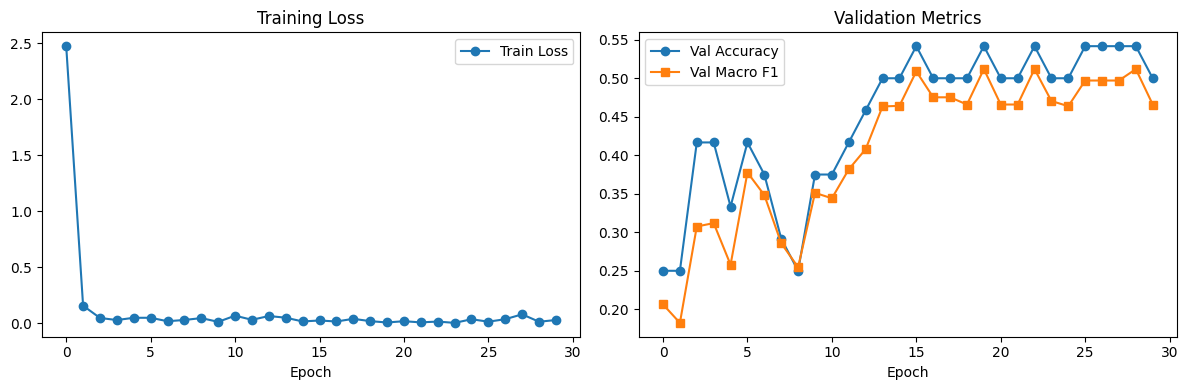

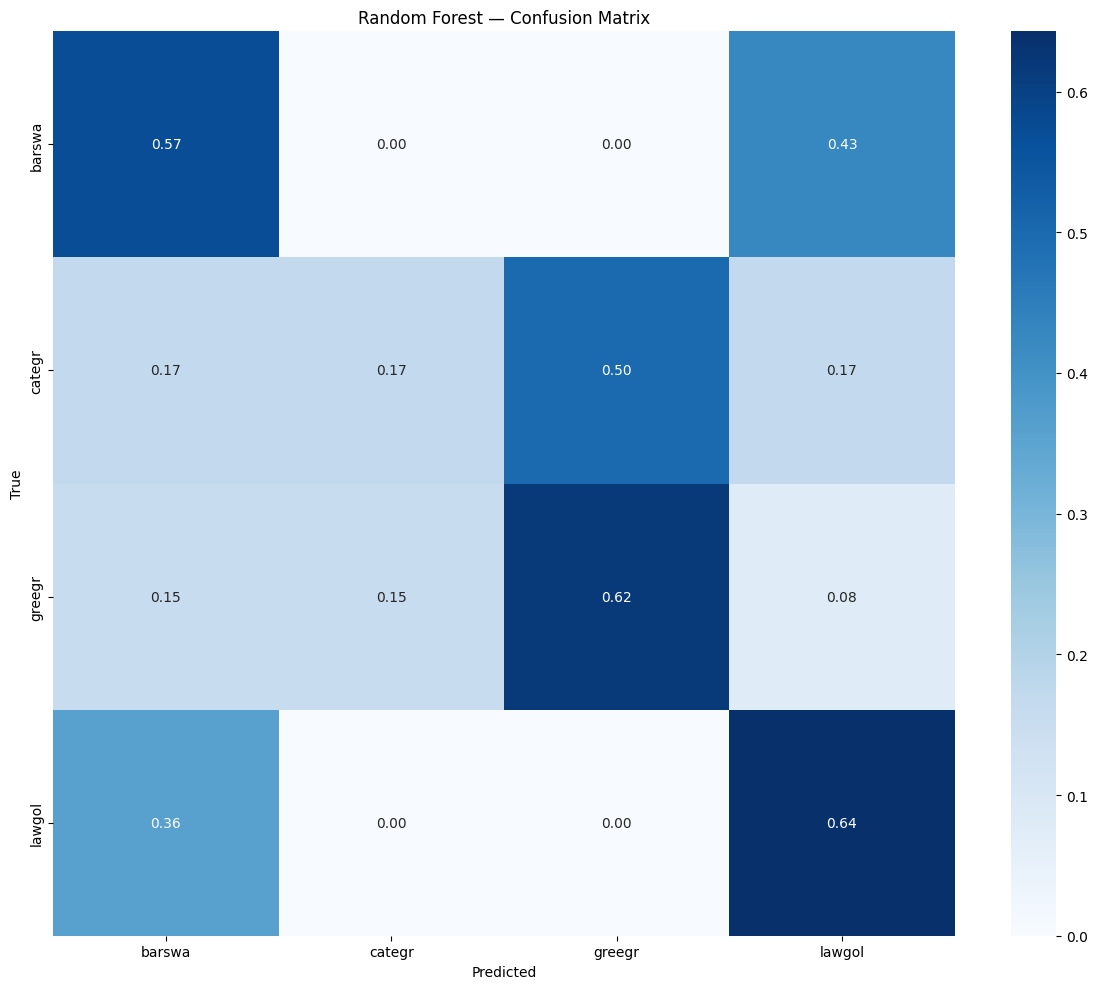

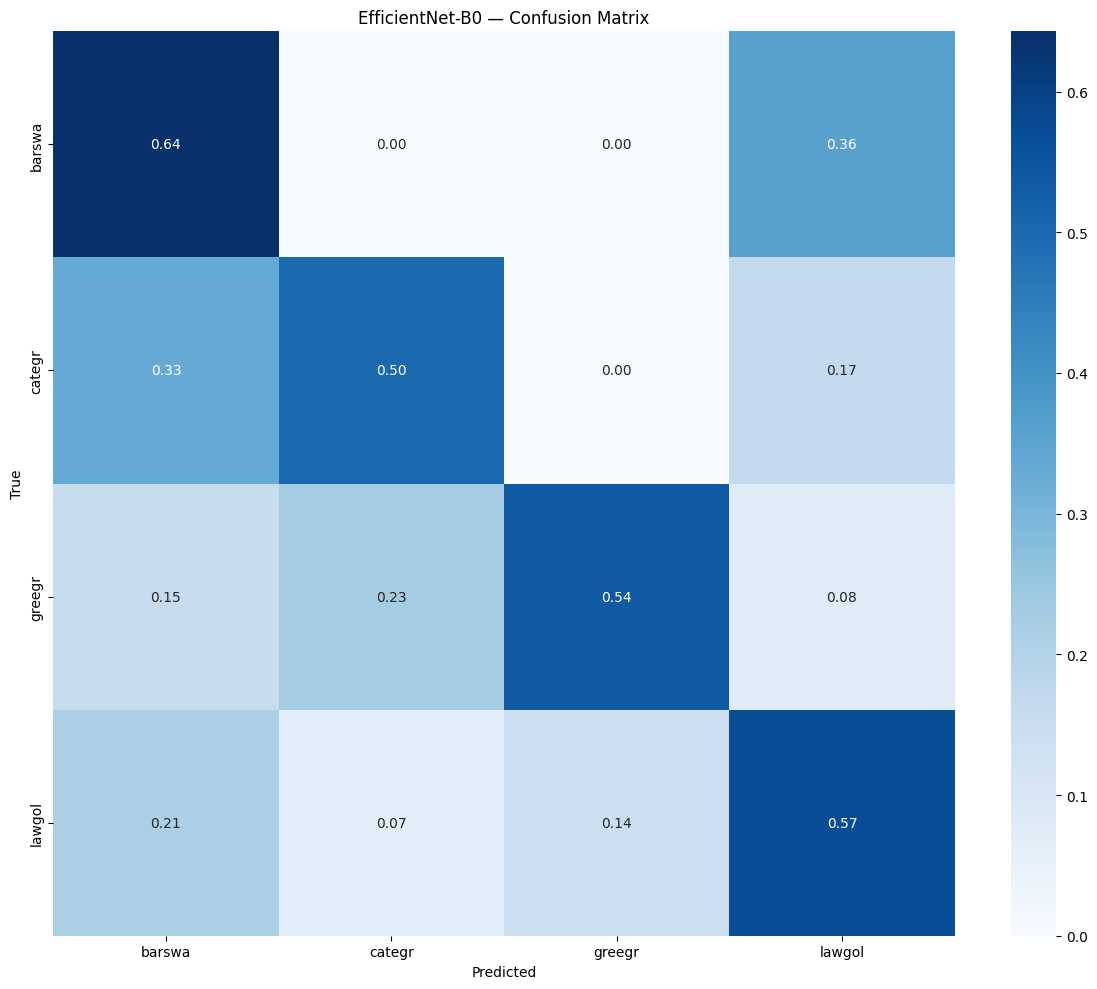

In [18]:
def plot_training_curves(history: dict, save_path: Path) -> None:
    """Plot loss and validation F1 curves for the CNN."""
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

    ax1.plot(history['train_loss'], marker='o', label='Train Loss')
    ax1.set_title('Training Loss')
    ax1.set_xlabel('Epoch')
    ax1.legend()

    ax2.plot(history['val_acc'],  marker='o', label='Val Accuracy')
    ax2.plot(history['val_f1'],   marker='s', label='Val Macro F1')
    ax2.set_title('Validation Metrics')
    ax2.set_xlabel('Epoch')
    ax2.legend()

    plt.tight_layout()
    plt.savefig(save_path, dpi=150)
    plt.show()


def plot_confusion_matrix(y_true, y_pred, class_names, title: str, save_path: Path) -> None:
    """Plot normalized confusion matrix."""
    cm = confusion_matrix(y_true, y_pred, normalize='true')
    fig, ax = plt.subplots(figsize=(12, 10))
    sns.heatmap(
        cm, annot=True, fmt='.2f', cmap='Blues',
        xticklabels=class_names, yticklabels=class_names, ax=ax
    )
    ax.set_title(title)
    ax.set_xlabel('Predicted')
    ax.set_ylabel('True')
    plt.tight_layout()
    plt.savefig(save_path, dpi=150)
    plt.show()


# Training curves
plot_training_curves(cnn_results['history'], OUTPUTS_DIR / 'cnn_training_curves.png')

# Confusion matrices
plot_confusion_matrix(
    test_data['y'], rf_results['preds'], le.classes_,
    'Random Forest — Confusion Matrix', OUTPUTS_DIR / 'rf_confusion_matrix.png'
)
plot_confusion_matrix(
    test_data['y'], cnn_results['preds'], le.classes_,
    'EfficientNet-B0 — Confusion Matrix', OUTPUTS_DIR / 'cnn_confusion_matrix.png'
)


=== MODEL COMPARISON ===
          Model  Test Accuracy  Macro F1
 Naive Baseline       0.276596  0.108333
  Random Forest       0.553191  0.500717
EfficientNet-B0       0.574468  0.562407


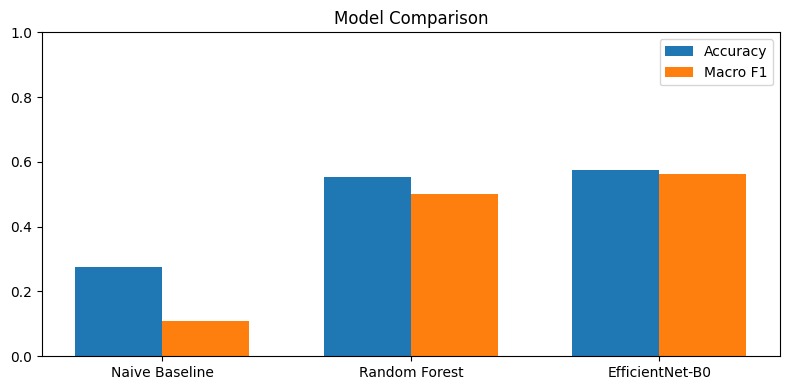

In [19]:
# ─── Summary table ────────────────────────────────────────────────────────────
results_summary = pd.DataFrame([
    {'Model': baseline_results['model'], 'Test Accuracy': baseline_results['accuracy'], 'Macro F1': baseline_results['macro_f1']},
    {'Model': rf_results['model'],       'Test Accuracy': rf_results['accuracy'],       'Macro F1': rf_results['macro_f1']},
    {'Model': cnn_results['model'],      'Test Accuracy': cnn_results['accuracy'],      'Macro F1': cnn_results['macro_f1']},
])

print('\n=== MODEL COMPARISON ===')
print(results_summary.to_string(index=False))
results_summary.to_csv(OUTPUTS_DIR / 'model_comparison.csv', index=False)

# Bar chart
fig, ax = plt.subplots(figsize=(8, 4))
x = np.arange(len(results_summary))
width = 0.35
ax.bar(x - width/2, results_summary['Test Accuracy'], width, label='Accuracy')
ax.bar(x + width/2, results_summary['Macro F1'],      width, label='Macro F1')
ax.set_xticks(x)
ax.set_xticklabels(results_summary['Model'])
ax.set_ylim(0, 1)
ax.set_title('Model Comparison')
ax.legend()
plt.tight_layout()
plt.savefig(OUTPUTS_DIR / 'model_comparison.png', dpi=150)
plt.show()

## 9. Experiment — Training Set Size Sensitivity

**Question**: How does each model's macro F1 change as we reduce the number of training samples per class?

**Why it matters**: Bird call datasets are often imbalanced. Understanding the data-efficiency of each approach informs which model to deploy when only limited labeled audio is available.

**Method**: Train both RF and CNN at fractions [10%, 25%, 50%, 75%, 100%] of the training set, evaluate on the fixed test set.

In [20]:
def subsample_train(train_data: dict, fraction: float, seed: int = SEED) -> dict:
    """
    Subsample the training set to a given fraction, stratified by class.

    Args:
        train_data: Dict with 'mfcc', 'mel', 'y'
        fraction:   Fraction of training data to keep (0 < fraction <= 1)
        seed:       Random seed

    Returns:
        Subsampled dict
    """
    if fraction >= 1.0:
        return train_data

    idx = np.arange(len(train_data['y']))
    idx_sub, _ = train_test_split(
        idx, train_size=fraction, stratify=train_data['y'], random_state=seed
    )
    return {
        'mfcc': train_data['mfcc'][idx_sub],
        'mel':  train_data['mel'][idx_sub],
        'y':    train_data['y'][idx_sub],
    }


FRACTIONS = [0.10, 0.25, 0.50, 0.75, 1.00]
exp_results = {'fraction': [], 'rf_f1': [], 'cnn_f1': []}

for frac in FRACTIONS:
    print(f'\n── Fraction: {int(frac*100)}% ──')
    sub_train = subsample_train(train_data, frac)
    n_samples = len(sub_train['y'])
    print(f'   Training samples: {n_samples}')

    # Random Forest
    rf_exp = RandomForestClassifier(n_estimators=200, class_weight='balanced', n_jobs=-1, random_state=SEED)
    rf_exp.fit(sub_train['mfcc'], sub_train['y'])
    rf_preds = rf_exp.predict(test_data['mfcc'])
    rf_f1 = f1_score(test_data['y'], rf_preds, average='macro', zero_division=0)

    # CNN — train for fewer epochs to keep runtime manageable
    exp_epochs = max(3, int(EPOCHS * frac))  # scale epochs with data size
    cnn_exp_res = train_cnn(sub_train, val_data, test_data, NUM_CLASSES, epochs=exp_epochs)
    cnn_f1 = cnn_exp_res['macro_f1']

    exp_results['fraction'].append(frac)
    exp_results['rf_f1'].append(rf_f1)
    exp_results['cnn_f1'].append(cnn_f1)

    print(f'   RF F1: {rf_f1:.4f} | CNN F1: {cnn_f1:.4f}')

exp_df = pd.DataFrame(exp_results)
exp_df.to_csv(OUTPUTS_DIR / 'experiment_train_size_sensitivity.csv', index=False)
print(exp_df)


── Fraction: 10% ──
   Training samples: 16
Epoch [01/3] Loss: 4.7741 | Val Acc: 0.2500 | Val F1: 0.1868
Epoch [02/3] Loss: 0.7696 | Val Acc: 0.2917 | Val F1: 0.2159
Epoch [03/3] Loss: 0.0174 | Val Acc: 0.2917 | Val F1: 0.2159

[EfficientNet-B0] Test Accuracy: 0.2340 | Test Macro F1: 0.1665
              precision    recall  f1-score   support

      barswa       0.26      0.57      0.36        14
      categr       0.00      0.00      0.00         6
      greegr       0.33      0.15      0.21        13
      lawgol       0.17      0.07      0.10        14

    accuracy                           0.23        47
   macro avg       0.19      0.20      0.17        47
weighted avg       0.22      0.23      0.19        47

   RF F1: 0.3739 | CNN F1: 0.1665

── Fraction: 25% ──
   Training samples: 40
Epoch [01/7] Loss: 3.6309 | Val Acc: 0.2917 | Val F1: 0.1952
Epoch [02/7] Loss: 0.6091 | Val Acc: 0.2083 | Val F1: 0.1414
Epoch [03/7] Loss: 0.1539 | Val Acc: 0.2083 | Val F1: 0.1422
Epoch [04/

Epoch [01/15] Loss: 4.0596 | Val Acc: 0.1250 | Val F1: 0.0868
Epoch [02/15] Loss: 0.8496 | Val Acc: 0.1667 | Val F1: 0.1107
Epoch [03/15] Loss: 0.0799 | Val Acc: 0.2083 | Val F1: 0.1760
Epoch [04/15] Loss: 0.0270 | Val Acc: 0.2083 | Val F1: 0.1682
Epoch [05/15] Loss: 0.0180 | Val Acc: 0.1667 | Val F1: 0.1339
Epoch [06/15] Loss: 0.0026 | Val Acc: 0.2083 | Val F1: 0.1825
Epoch [07/15] Loss: 0.0010 | Val Acc: 0.2917 | Val F1: 0.2917
Epoch [08/15] Loss: 0.0038 | Val Acc: 0.2500 | Val F1: 0.2616
Epoch [09/15] Loss: 0.0058 | Val Acc: 0.3333 | Val F1: 0.3398
Epoch [10/15] Loss: 0.0019 | Val Acc: 0.3750 | Val F1: 0.3832
Epoch [11/15] Loss: 0.0023 | Val Acc: 0.4167 | Val F1: 0.3806
Epoch [12/15] Loss: 0.0087 | Val Acc: 0.4167 | Val F1: 0.4021
Epoch [13/15] Loss: 0.0024 | Val Acc: 0.4583 | Val F1: 0.4510
Epoch [14/15] Loss: 0.0019 | Val Acc: 0.3750 | Val F1: 0.3662
Epoch [15/15] Loss: 0.0009 | Val Acc: 0.4167 | Val F1: 0.4140

[EfficientNet-B0] Test Accuracy: 0.3830 | Test Macro F1: 0.3647
     

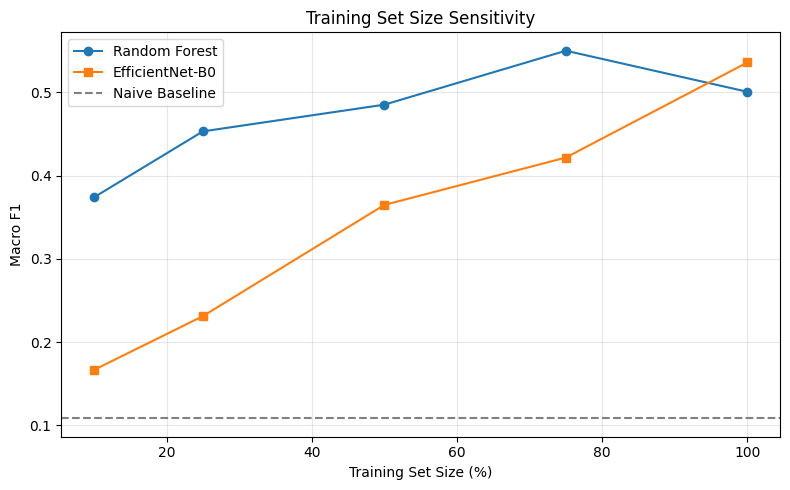


Interpretation:
- If CNN outperforms RF at full data but underperforms at low data fractions,
  it confirms that deep learning needs more data to generalize.
- RF showing earlier saturation suggests MFCCs capture sufficient structure
  for small-data regimes. The CNN's advantage grows with data volume.


In [21]:
# ─── Plot experiment results ───────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(exp_df['fraction'] * 100, exp_df['rf_f1'],  marker='o', label='Random Forest')
ax.plot(exp_df['fraction'] * 100, exp_df['cnn_f1'], marker='s', label='EfficientNet-B0')
ax.axhline(baseline_results['macro_f1'], linestyle='--', color='gray', label='Naive Baseline')

ax.set_xlabel('Training Set Size (%)')
ax.set_ylabel('Macro F1')
ax.set_title('Training Set Size Sensitivity')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(OUTPUTS_DIR / 'experiment_train_size_sensitivity.png', dpi=150)
plt.show()

print('\nInterpretation:')
print('- If CNN outperforms RF at full data but underperforms at low data fractions,')
print('  it confirms that deep learning needs more data to generalize.')
print('- RF showing earlier saturation suggests MFCCs capture sufficient structure')
print('  for small-data regimes. The CNN\'s advantage grows with data volume.')

## 10. Save Final Model

Select the best model (typically EfficientNet-B0) based on test Macro F1.

In [22]:
def save_final_model(results_list: list, le: LabelEncoder) -> None:
    """
    Save the best model's metadata and label encoder for use in app.py.

    Args:
        results_list: List of result dicts from each model
        le:           Fitted LabelEncoder
    """
    best = max(results_list, key=lambda r: r['macro_f1'])
    print(f'Best model: {best["model"]} (Macro F1: {best["macro_f1"]:.4f})')

    # Save label encoder
    joblib.dump(le, MODELS_DIR / 'label_encoder.pkl')

    # Save summary JSON for app.py
    import json
    summary = {
        'best_model': best['model'],
        'test_accuracy': round(best['accuracy'], 4),
        'test_macro_f1': round(best['macro_f1'], 4),
        'classes': le.classes_.tolist(),
        'num_classes': NUM_CLASSES,
        'audio_duration': AUDIO_DURATION,
        'sample_rate': SAMPLE_RATE,
    }
    with open(MODELS_DIR / 'model_config.json', 'w') as f:
        json.dump(summary, f, indent=2)

    print('Saved: label_encoder.pkl, model_config.json, efficientnet_best.pt')


save_final_model(
    [baseline_results, rf_results, cnn_results],
    le
)

print('\n✅ All done. Artifacts saved to ../models/ and ../data/outputs/')

Best model: EfficientNet-B0 (Macro F1: 0.5624)
Saved: label_encoder.pkl, model_config.json, efficientnet_best.pt

✅ All done. Artifacts saved to ../models/ and ../data/outputs/
